## Imports

In [1]:
import os
import SimpleITK as sitk
import numpy as np
import nibabel as nib
from monai.utils import set_determinism
from tqdm import tqdm
from intensity_normalization.typing import TissueType
from intensity_normalization.normalize.fcm import FCMNormalize
import pandas as pd
import voxelmorph as vxm
import itk
from multiAtlasUtils import (visualize_histograms, create_data_files,
                   dice_coefficient, show_results, load_and_preprocess,compute_mattes_mi, voxmorph_register)
set_determinism(seed=42)

## Pre-process and visualize

In [2]:
train_files = create_data_files("Training_Set", is_train=True, is_val=False)
val_files = create_data_files("Validation_Set", is_train=False, is_val=True)
test_files = create_data_files("Test_Set", is_train=False, is_val=False)
# load_and_preprocess(train_files, "train")
# load_and_preprocess(val_files, "val")
# load_and_preprocess(test_files, "test")

In [3]:
train_root_dir = "Training_Set"
subdirs = sorted(os.listdir(train_root_dir))
train_images = []
train_labels = []

for subdir in subdirs:
    train_img_path = os.path.join(train_root_dir, subdir, f"{subdir}_normalized.nii.gz")
    train_lbl_path = os.path.join(train_root_dir, subdir, f"{subdir}_seg.nii.gz")
    train_images.append(train_img_path)
    train_labels.append(train_lbl_path)

val_root_dir = "Validation_Set"
subdirs = sorted(os.listdir(val_root_dir))
val_images = []
val_labels = []

for subdir in subdirs:
    val_img_path = os.path.join(val_root_dir, subdir, f"{subdir}_normalized.nii.gz")
    val_lbl_path = os.path.join(val_root_dir, subdir, f"{subdir}_seg.nii.gz")
    val_images.append(val_img_path)
    val_labels.append(val_lbl_path)

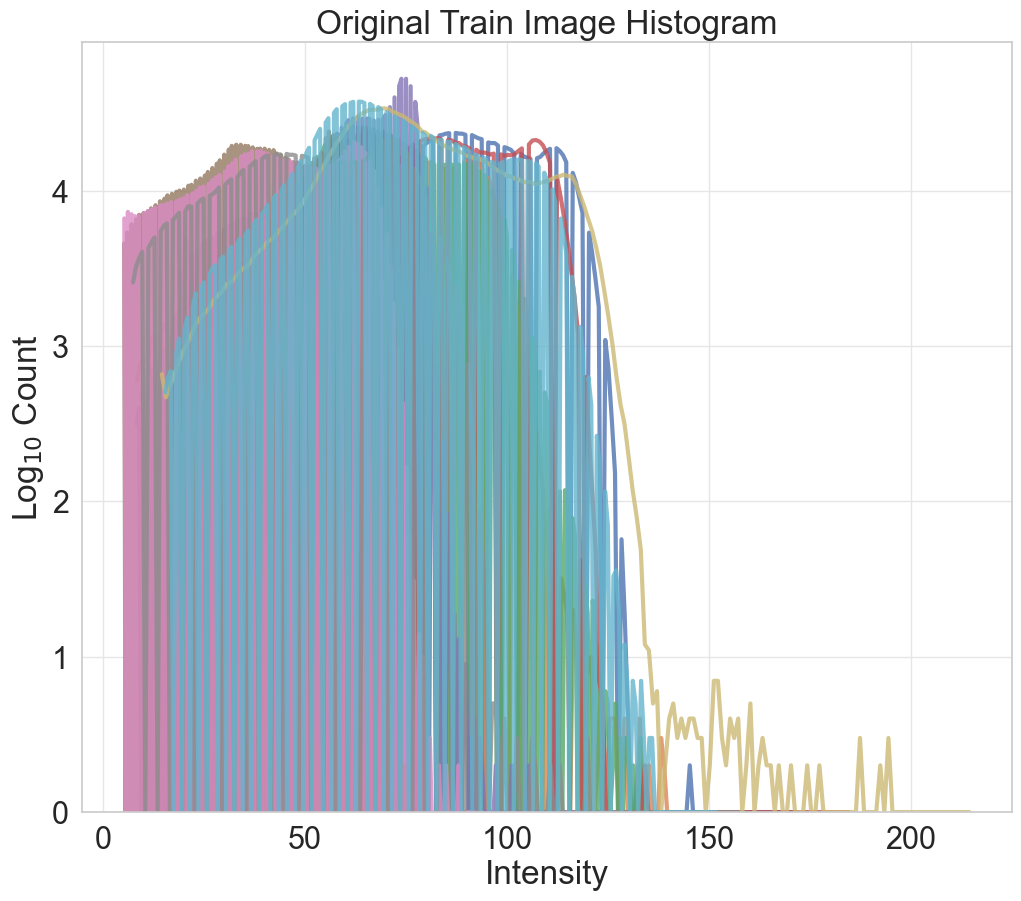

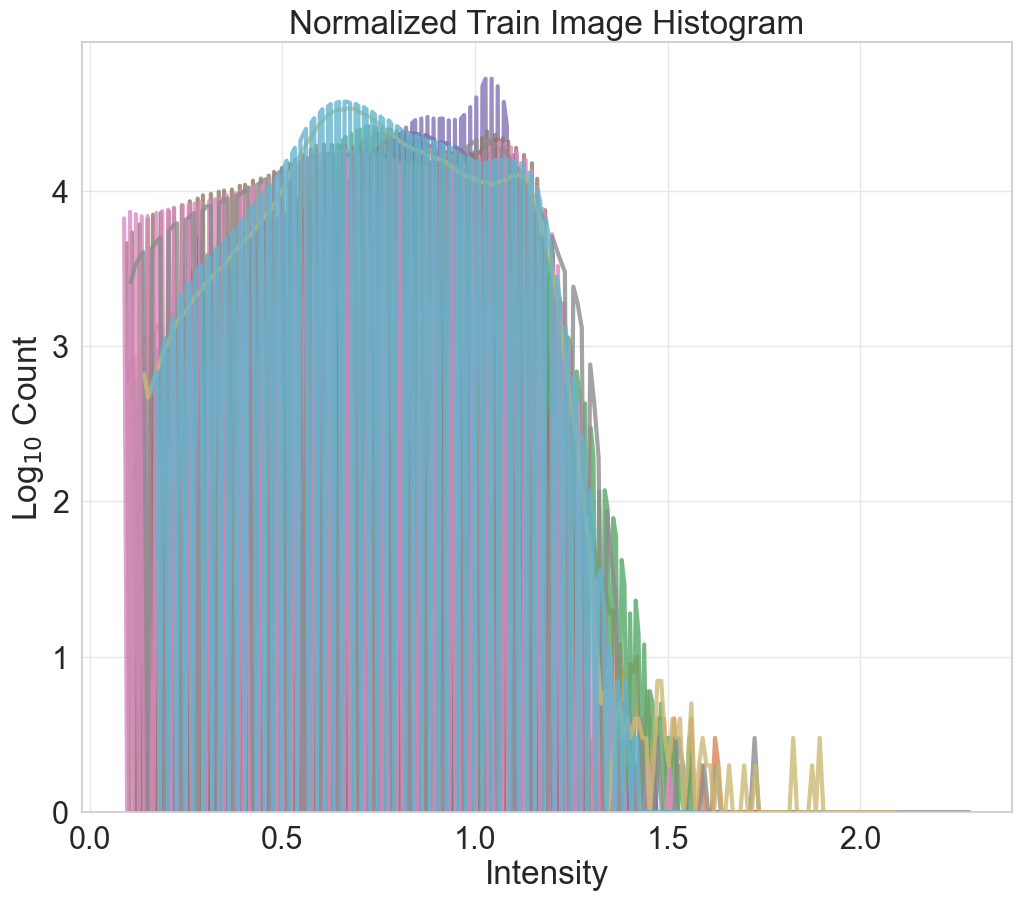

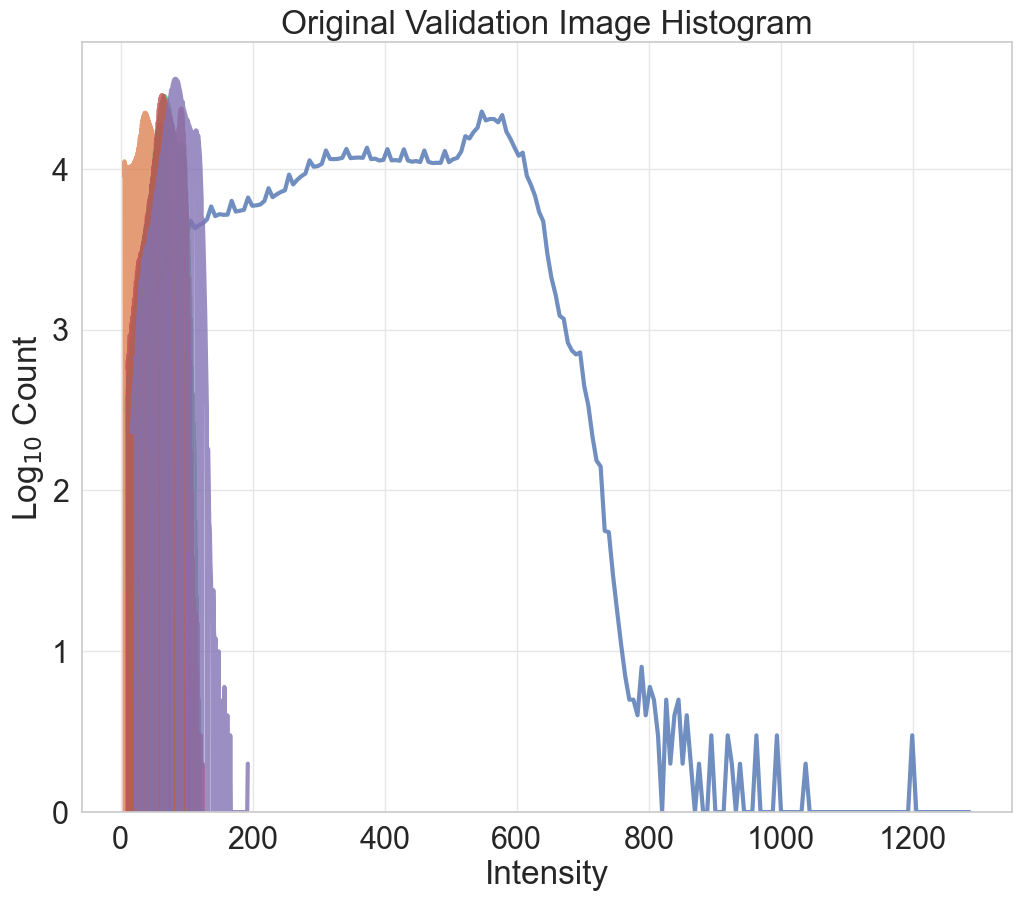

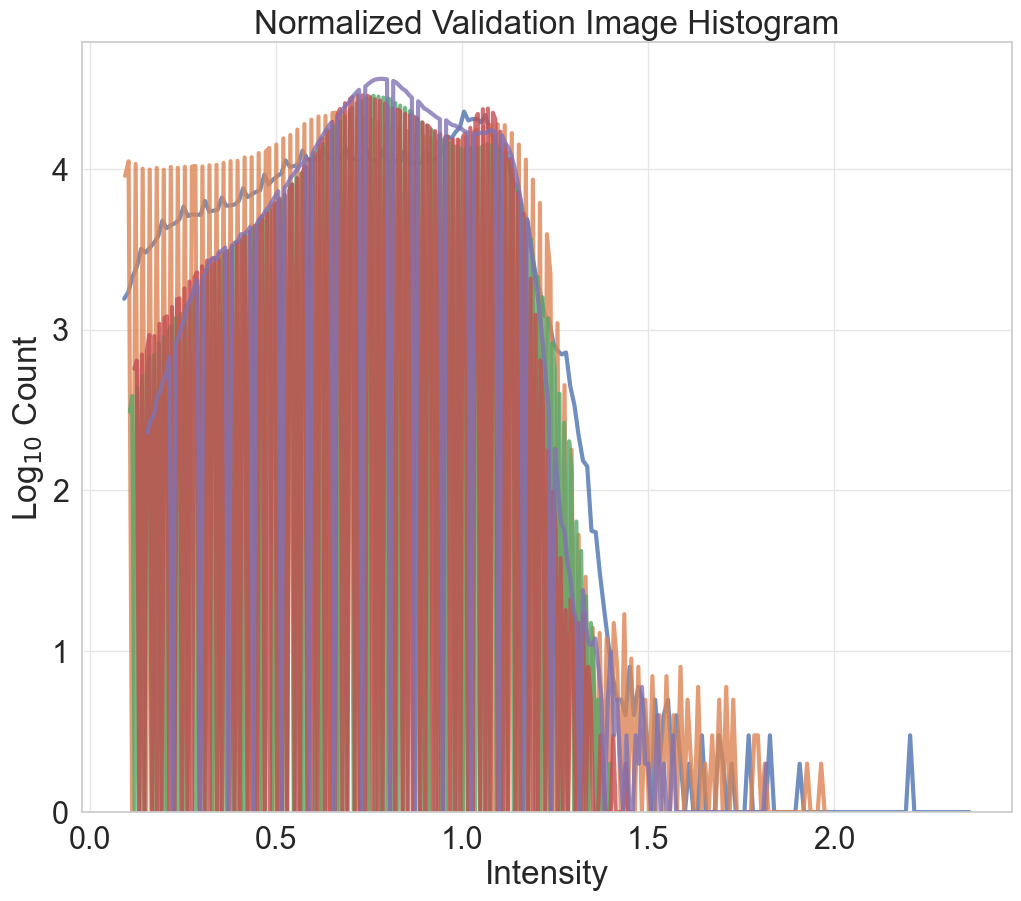

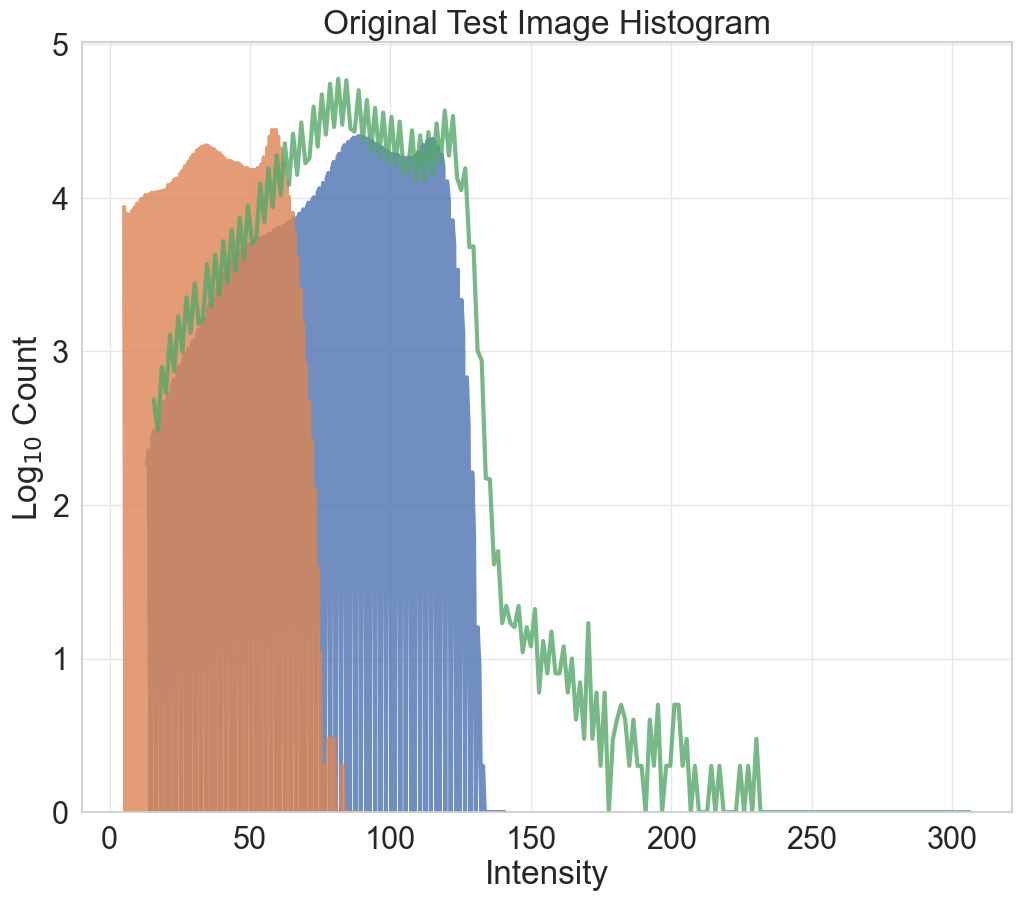

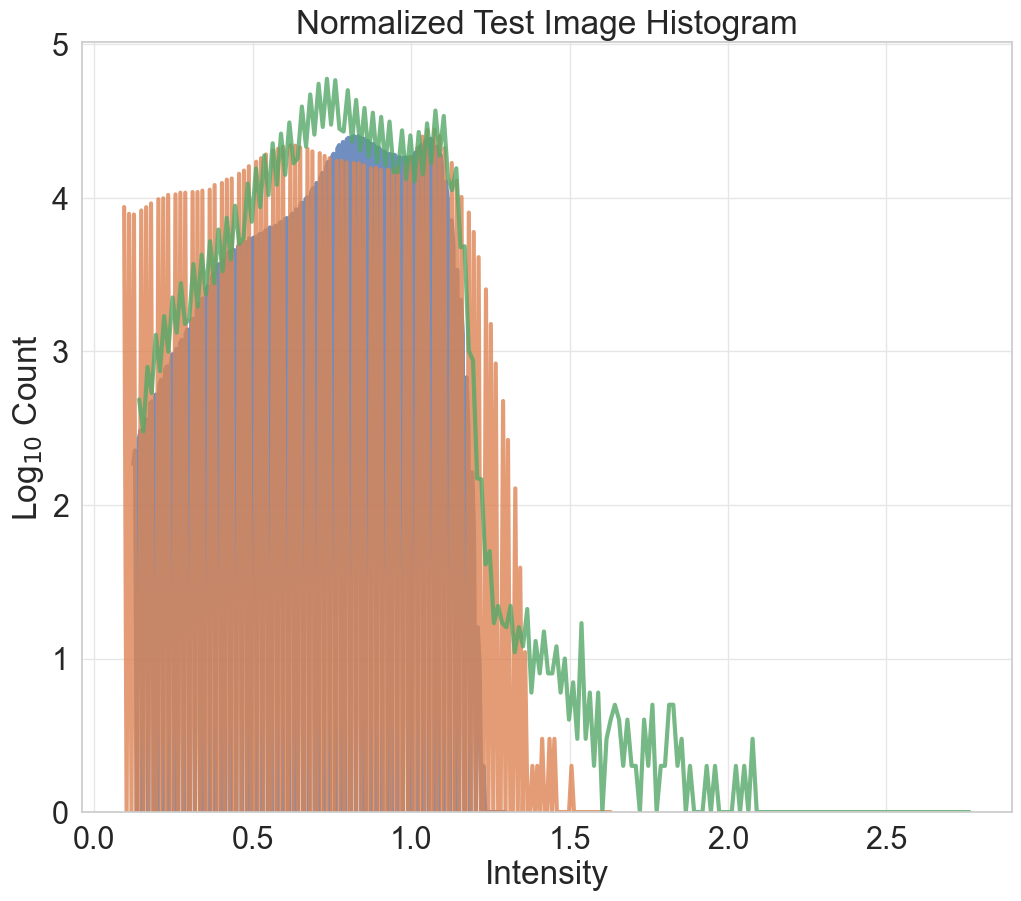

In [5]:
# Visualize histograms for training images
train_images = [nib.load(file["image"]).get_fdata() for file in train_files]
visualize_histograms(train_images, title="Original Train Image Histogram")

# Normalize training images and visualize
fcm_norm = FCMNormalize(tissue_type=TissueType.WM)  # normalize object
fcm_normed = [fcm_norm(img) for img in train_images]
visualize_histograms(fcm_normed, title="Normalized Train Image Histogram")

# Visualize histograms for validation images
val_images = [nib.load(file["image"]).get_fdata() for file in val_files]
visualize_histograms(val_images, title="Original Validation Image Histogram")

# Normalize validation images and visualize
fcm_normed_val = [fcm_norm(img) for img in val_images]
visualize_histograms(fcm_normed_val, title="Normalized Validation Image Histogram")

# Visualize histograms for test images
test_images = [nib.load(file["image"]).get_fdata() for file in test_files]
visualize_histograms(test_images, title="Original Test Image Histogram")

# Normalize test images and visualize
fcm_normed_test = [fcm_norm(img) for img in test_images]
visualize_histograms(fcm_normed_test, title="Normalized Test Image Histogram")

## ITK Registration

In [8]:
# Iterate through each validation image
for val_file in tqdm(val_images, desc="Validation Images"):
    df_val = None
    if not val_file.endswith(('.nii', '.nii.gz')):
        continue
    val_image = itk.imread(val_file, itk.F)
    val_label = itk.imread(val_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)

    # Iterate through each training image
    for train_file in tqdm(train_images, desc="Training Images"):
        if not train_file.endswith(('.nii', '.nii.gz')):
            continue
        train_image = itk.imread(train_file, itk.F)
        train_label = itk.imread(train_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)

        # Create a parameter object for registration
        parameter_object = itk.ParameterObject.New()
        parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.affine.txt")
        parameter_object.AddParameterFile("parameters/9/Parameters.Par0009.elastic.txt")

        # Perform the registration
        result_image, result_transform_parameters = itk.elastix_registration_method(
            val_image, train_image,
            parameter_object=parameter_object,
            log_to_console=False)

        # Set the ResampleInterpolator of the result_transform_parameters
        result_transform_parameters.SetParameter("ResampleInterpolator", ["FinalNearestNeighborInterpolator"])

        # Transform the training label using the result transform parameters
        transformed_label = itk.transformix_filter(train_label, result_transform_parameters)

        # Calculate dice score between validation label and transformed training label
        csf = dice_coefficient(itk.GetArrayFromImage(transformed_label), itk.GetArrayFromImage(val_label), 1)
        gm = dice_coefficient(itk.GetArrayFromImage(transformed_label), itk.GetArrayFromImage(val_label), 2)
        wm = dice_coefficient(itk.GetArrayFromImage(transformed_label), itk.GetArrayFromImage(val_label), 3)
        
        # Save the registered image and transformed label with appropriate suffix
        registered_image_name = os.path.basename(train_file).replace("_normalized.nii.gz", f"_to_{os.path.basename(val_file)}")
        registered_image_output_path = os.path.join("output", registered_image_name)
        itk.imwrite(result_image, registered_image_output_path)

        transformed_label_name = os.path.basename(train_file).replace("_normalized.nii.gz", f"_label_to_{os.path.basename(val_file)}")
        transformed_label_output_path = os.path.join("output", transformed_label_name) 
        itk.imwrite(transformed_label, transformed_label_output_path)
        
        mmi = compute_mattes_mi(registered_image_output_path, val_file)
        # save results in dataframe
        dice = [csf, gm, wm]
        metric = mmi
        train_id = os.path.basename(train_file)
        val_id = os.path.basename(val_file)
        df = pd.DataFrame([[train_id] + dice+[metric]], columns=['train_id', 'CSF', 'GM', 'WM', 'metric'])
        df_val = pd.concat([df_val, df], ignore_index=True)
    
    # arange in descending order (most negative metric is the best)
    df_val = df_val.sort_values(by='metric', ascending=True)
    df_val.to_csv(str(f'output/registration_result_{val_id}.csv'), index=False)

Validation Images: 100%|██████████| 5/5 [15:24<00:00, 184.89s/it]


## Multi Atlas

Now we have registered all train images to individual validation images and transformed their respective labels to the validation images.
Next we have to use a multi-atlas strategy to combine these labels to get one label per validation or test image.

### Mean Atlas

In [18]:
df_mean_atlas = None
save_path = "mean_atlas_val_pred/"
file_dir = "output"
os.makedirs(save_path, exist_ok=True)
for val_file in tqdm(val_images, desc="Validation Images"):
    val_image = itk.imread(val_file, itk.F)
    val_np = itk.GetArrayFromImage(val_image)

    # accumulated label array
    accumulated_label = np.zeros((4,) + val_np.shape)
    for train_file in tqdm(train_images, desc="Training Images"):
        if not train_file.endswith(('.nii', '.nii.gz')):
            continue
        moved_label_path = os.path.join(file_dir, os.path.basename(train_file).replace("_normalized.nii.gz", f"_label_to_{os.path.basename(val_file)}"))
        moved_label = itk.GetArrayFromImage(itk.imread(moved_label_path, itk.F))
        # accumulate per tissue
        for tissue in range(1, 4):
            accumulated_label[tissue] += (moved_label==tissue)
    # divide by the number of labels
    accumulated_label /= len(train_images)

    # Now we can take the argmax of the accumulated label to get the final mean atlas label
    mean_label = np.argmax(accumulated_label, axis=0)
    # save the mean label
    mean_label_itk = itk.GetImageFromArray(mean_label.astype(np.uint8))
    mean_label_itk.CopyInformation(val_image)
    itk.imwrite(mean_label_itk, f'{save_path}/mean_label_{os.path.basename(val_file)}')

Validation Images: 100%|██████████| 5/5 [00:04<00:00,  1.03it/s]


Dice Score: CSF: 0.8166986115656117, GM: 0.79869982441096, WM: 0.8474191419141914, Avg: 0.8209391926302544


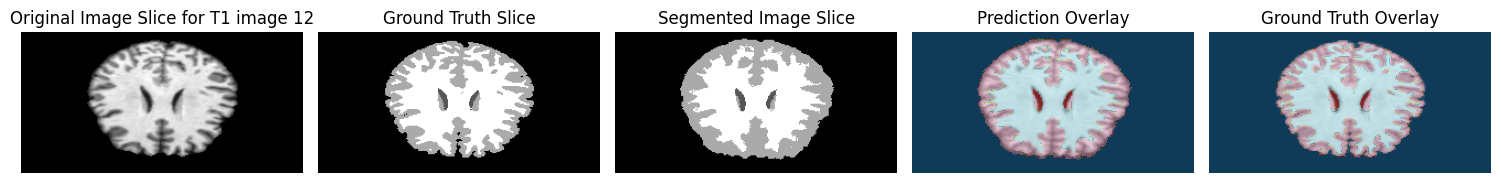

Dice Score: CSF: 0.8206724331366942, GM: 0.7959575392675785, WM: 0.846996860830136, Avg: 0.8212089444114695


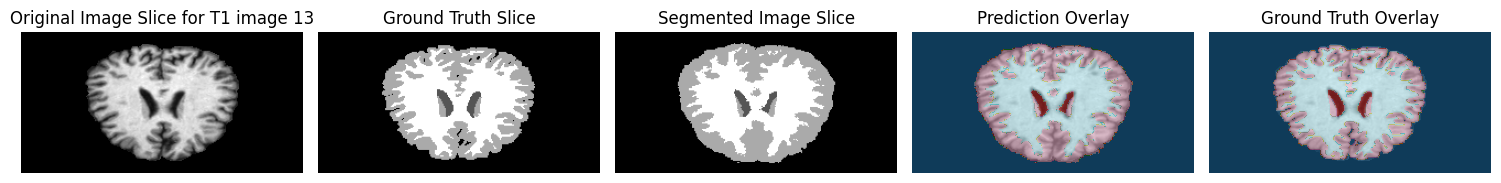

Dice Score: CSF: 0.7912211592571751, GM: 0.846271757473043, WM: 0.815703920319086, Avg: 0.8177322790164346


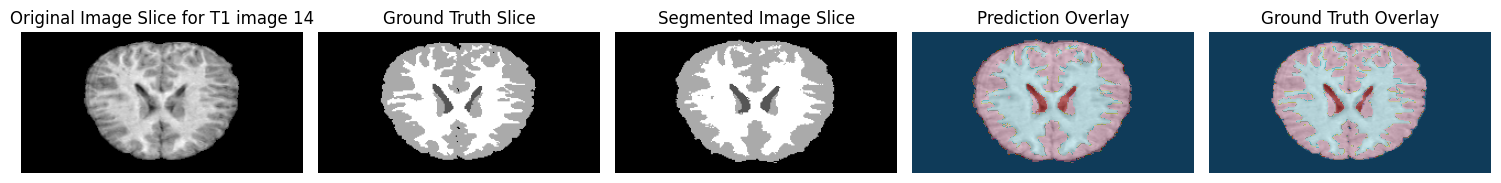

Dice Score: CSF: 0.8428153501979005, GM: 0.8426629525075487, WM: 0.8488380306562124, Avg: 0.844772111120554


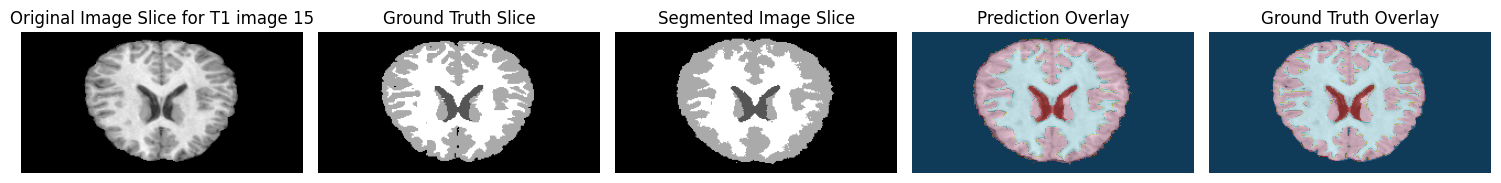

Dice Score: CSF: 0.8807704066034852, GM: 0.8575458086482356, WM: 0.8239139338950098, Avg: 0.8540767163822435


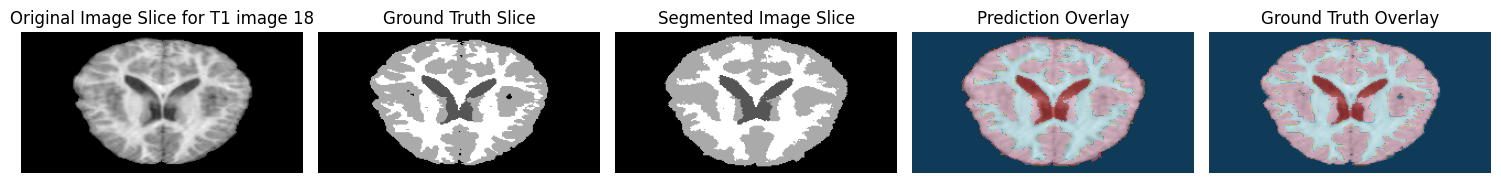

In [9]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"mean_atlas_val_pred/mean_label_IBSR_{idx}_normalized.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    except Exception as e:
        print(f"Error: {e}")

### Weighted Atlas (global)

In [15]:
df_weightedAtlas = None
save_path = "weighted_atlas_val_pred/"
os.makedirs(save_path, exist_ok=True)
file_dir = "output"
for val_file in tqdm(val_images, desc="Validation Images"):
    val_image = itk.imread(val_file, itk.F)
    val_np = itk.GetArrayFromImage(val_image)
    val_id = os.path.basename(val_file)
    # accumulated label array
    weighted_atlas = np.zeros((4,) + val_np.shape)
    df_mostSimilar = pd.read_csv(f"output/registration_result_{val_id}.csv")
    # get metric values and sum them up
    sigma = df_mostSimilar['metric'].abs().sum()
    for train_file in tqdm(train_images, desc="Training Images"):
        if not train_file.endswith(('.nii', '.nii.gz')):
            continue
        moved_label_path = os.path.join(file_dir, os.path.basename(train_file).replace("_normalized.nii.gz", f"_label_to_{os.path.basename(val_file)}"))
        moved_label = itk.GetArrayFromImage(itk.imread(moved_label_path, itk.F))
        train_id = os.path.basename(train_file)
        simMetric = df_mostSimilar[df_mostSimilar['train_id']==train_id]['metric'].abs().values[0]
        # accumulate per tissue
        for tissue in range(1,4):
            weighted_atlas[tissue] += (moved_label==tissue)*(simMetric/sigma) #wieghting by the similarity metric

    # get argmax of the weighted atlas
    weighted_label = np.argmax(weighted_atlas, axis=0)
    # save the weighted label
    weighted_label_itk = itk.GetImageFromArray(weighted_label.astype(np.uint8))
    weighted_label_itk.CopyInformation(val_image)
    itk.imwrite(weighted_label_itk, f'{save_path}weighted_label_{os.path.basename(val_file)}')

Validation Images: 100%|██████████| 5/5 [00:07<00:00,  1.43s/it]


Dice Score: CSF: 0.8145346610494063, GM: 0.7967722306091097, WM: 0.8543566265539589, Avg: 0.8218878394041583


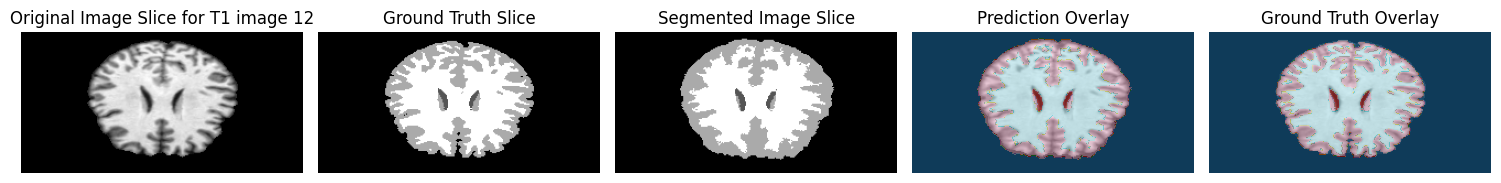

Dice Score: CSF: 0.8133014881499173, GM: 0.7909688326561776, WM: 0.8469957063443191, Avg: 0.8170886757168047


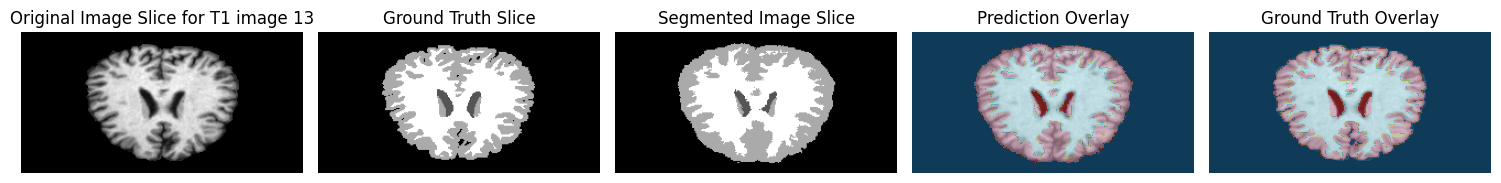

Dice Score: CSF: 0.7913963203270821, GM: 0.8404725898046708, WM: 0.8088455878750136, Avg: 0.8135714993355888


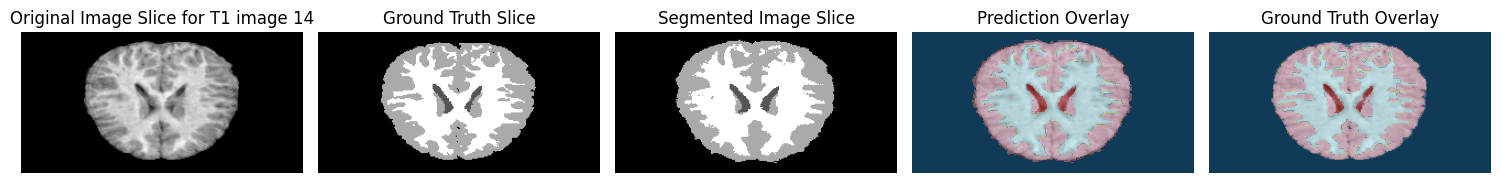

Dice Score: CSF: 0.8434015525758645, GM: 0.8386175450356318, WM: 0.8472425521637177, Avg: 0.843087216591738


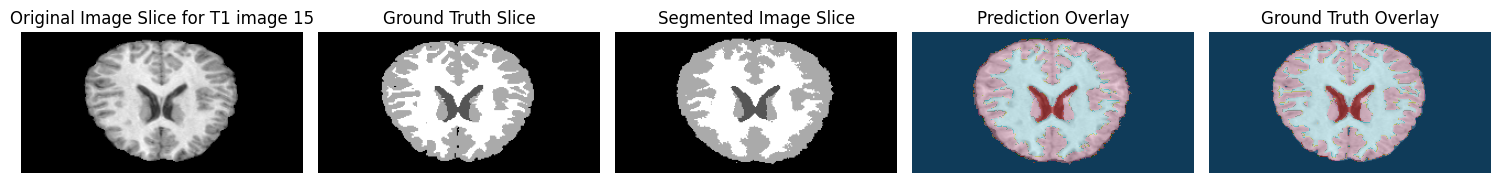

Dice Score: CSF: 0.8838971688397489, GM: 0.8542129969299151, WM: 0.8219473710999134, Avg: 0.8533525122898592


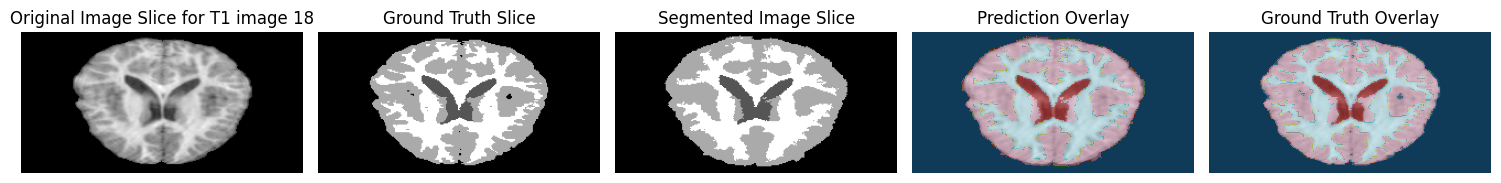

In [10]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"weighted_atlas_val_pred/weighted_label_IBSR_{idx}_normalized.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    except Exception as e:
        print(f"Error: {e}")

### Weighted Atlas (local)

In [13]:
def compute_slice_similarity(moved_label_slice, val_slice):
    """
    Compute similarity metric between two image slices.
    
    Parameters:
    -----------
    moved_label_slice : ndarray
        2D slice from moved label image
    val_slice : ndarray
        2D slice from validation image
    
    Returns:
    --------
    float
        Similarity metric for the entire slice
    """
    # Compute global similarity metrics
    # Options include:
    # 1. Mean Squared Error (lower is better)
    mse = np.mean((moved_label_slice - val_slice) ** 2)
    
    # 2. Normalized Cross-Correlation
    # norm_cc = np.corrcoef(moved_label_slice.flatten(), val_slice.flatten())[0, 1]
    
    # Invert MSE to make it a similarity metric (higher is more similar)
    return 1 / (1 + mse)

In [14]:
df_weightedAtlas = None
save_path = "local_weighted_atlas_val_pred/"
os.makedirs(save_path, exist_ok=True)
file_dir = "output"
for val_file in tqdm(val_images, desc="Validation Images"):
    # Read validation image
    val_image = itk.imread(val_file, itk.F)
    val_np = itk.GetArrayFromImage(val_image)
    
    # Get image dimensions
    depth, height, width = val_np.shape
    
    # Initialize weighted atlas (4 channels: background + 3 tissues)
    weighted_atlas = np.zeros((4, depth, height, width), dtype=np.float32)
    
    # Iterate through each z-slice in the validation image
    for z in range(depth):
        # Initialize local weights for this slice
        local_weights = []
        local_labels = []
        
        # Process each training image
        for train_file in tqdm(train_images, desc=f"Training Images (Slice {z})"):
            # Skip non-nii files
            if not train_file.endswith(('.nii', '.nii.gz')):
                continue
            
            # Construct moved label path
            moved_label_path = os.path.join(
                file_dir, 
                os.path.basename(train_file).replace(
                    "_normalized.nii.gz", 
                    f"_label_to_{os.path.basename(val_file)}"
                )
            )
            
            # Read moved label
            try:
                moved_label = itk.GetArrayFromImage(itk.imread(moved_label_path, itk.F))
                
                # Compute slice-level similarity metric
                sim_metric = compute_slice_similarity(
                    moved_label[z], 
                    val_np[z]
                )
                
                # Store similarity and corresponding labels
                local_weights.append(sim_metric)
                local_labels.append(moved_label[z])
            
            except Exception as e:
                print(f"Error processing {moved_label_path} at slice {z}: {e}")
                continue
        
        # Normalize weights
        if local_weights:
            norm_weights = np.array(local_weights) / np.sum(local_weights)
            
            # Accumulate weighted atlas for this slice
            for label, weight in zip(local_labels, norm_weights):
                for tissue in range(1, 4):
                    weighted_atlas[tissue, z] += (label == tissue) * weight
    
    # Get argmax of the weighted atlas
    weighted_label = np.argmax(weighted_atlas, axis=0)
            
    # save the weighted label
    weighted_label_itk = itk.GetImageFromArray(weighted_label.astype(np.uint8))
    weighted_label_itk.CopyInformation(val_image)
    itk.imwrite(weighted_label_itk, f'{save_path}local_weighted_label_{os.path.basename(val_file)}')

Validation Images: 100%|██████████| 5/5 [06:21<00:00, 76.26s/it]


Dice Score: CSF: 0.8176827506501011, GM: 0.7960800281782323, WM: 0.8541432331583316, Avg: 0.8226353373288884


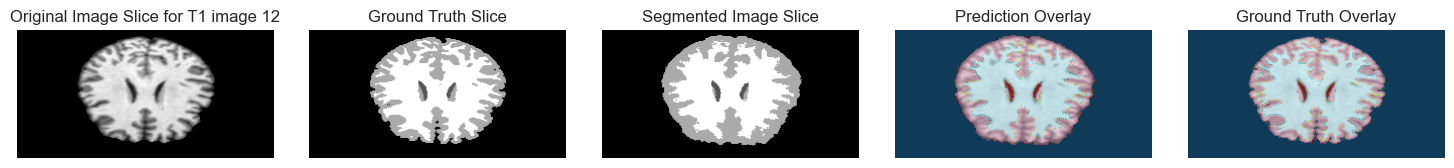

Dice Score: CSF: 0.8124424132974607, GM: 0.7896301377247333, WM: 0.8461168263869675, Avg: 0.8160631258030538


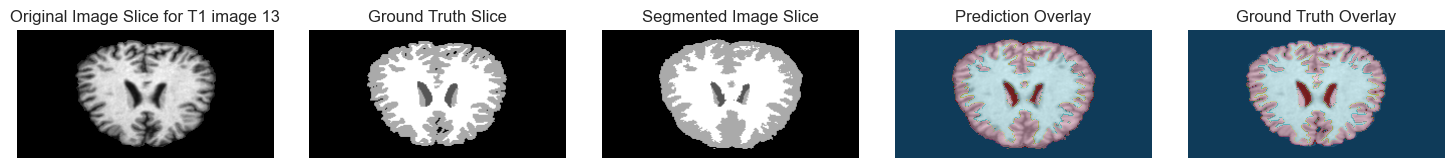

Dice Score: CSF: 0.7922744462452729, GM: 0.8367568176378662, WM: 0.804222873533963, Avg: 0.8110847124723675


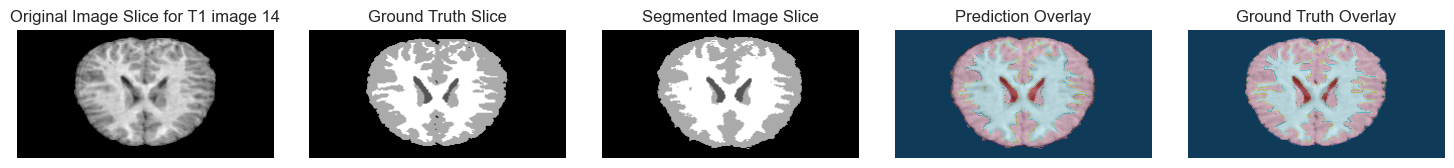

Dice Score: CSF: 0.8435103663731894, GM: 0.8380941010257787, WM: 0.8468472282678443, Avg: 0.8428172318889375


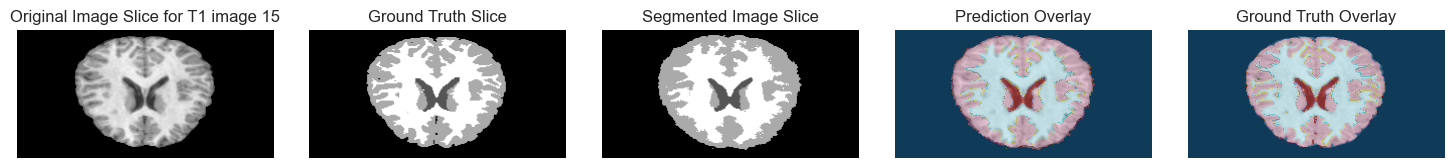

Dice Score: CSF: 0.8847193326981782, GM: 0.8543376540042895, WM: 0.8219273856891266, Avg: 0.8536614574638648


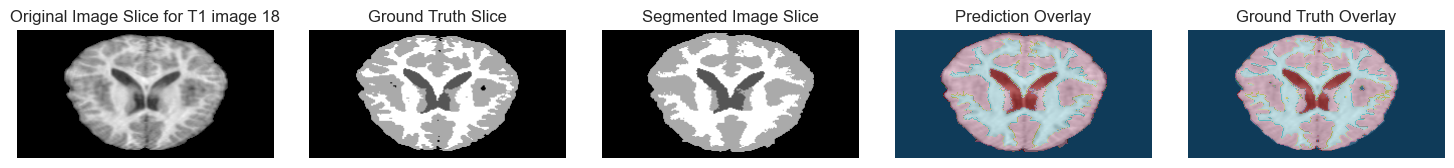

In [4]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"local_weighted_atlas_val_pred/local_weighted_label_IBSR_{idx}_normalized.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    except Exception as e:
        print(f"Error: {e}")

### Top Atlas

In [17]:
df_top_atlases = None
save_path = "top_atlas_val_pred/"
os.makedirs(save_path, exist_ok=True)
file_dir = "output"
for val_file in tqdm(val_images, desc="Validation Images"):
    val_image = itk.imread(val_file, itk.F)
    val_np = itk.GetArrayFromImage(val_image)
    accumulated_label = np.zeros((4,) + val_np.shape)
    df_mostSimilar = pd.read_csv(f"output/registration_result_{val_id}.csv")
    # get the top 3 atlases
    df_mostSimilar = df_mostSimilar.iloc[:3]
    # remove the last row if the metric values differences are greater than 0.05
    df_mostSimilar = df_mostSimilar.iloc[:-1] if df_mostSimilar['metric'].diff().abs().max()>0.05 else df_mostSimilar
    for train_file in tqdm(train_images, desc="Training Images"):
        if not train_file.endswith(('.nii', '.nii.gz')):
            continue
        moved_label_path = os.path.join(file_dir, os.path.basename(train_file).replace("_normalized.nii.gz", f"_label_to_{os.path.basename(val_file)}"))
        moved_label = itk.GetArrayFromImage(itk.imread(moved_label_path, itk.F))
        #accumulate per tissue
        for tissue in range(1,4):
            accumulated_label[tissue] += (moved_label==tissue)
    # divide by the number of labels
    accumulated_label /= len(df_mostSimilar['train_id'])
    
    # Now we can take the argmax of the accumulated label to get the final mean atlas label
    top_atlases_label = np.argmax(accumulated_label, axis=0)
    
    #save segmentation as nifti
    top_atlases_label_itk = itk.GetImageFromArray(top_atlases_label.astype(np.uint8))
    top_atlases_label_itk.CopyInformation(val_image)
    itk.imwrite(top_atlases_label_itk, f'{save_path}top_atlases_label_{os.path.basename(val_file)}')


Validation Images: 100%|██████████| 5/5 [00:05<00:00,  1.02s/it]


Dice Score: CSF: 0.8166986115656117, GM: 0.79869982441096, WM: 0.8474191419141914, Avg: 0.8209391926302544


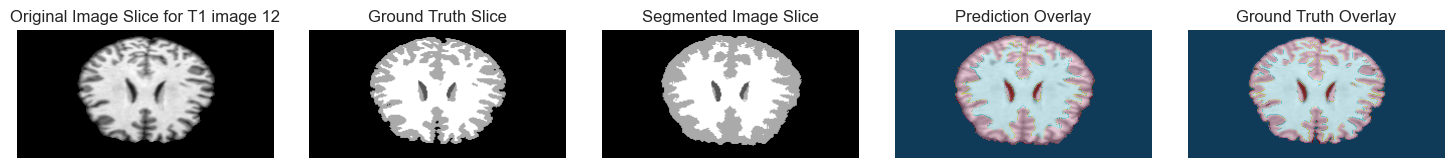

Dice Score: CSF: 0.8206724331366942, GM: 0.7959575392675785, WM: 0.846996860830136, Avg: 0.8212089444114695


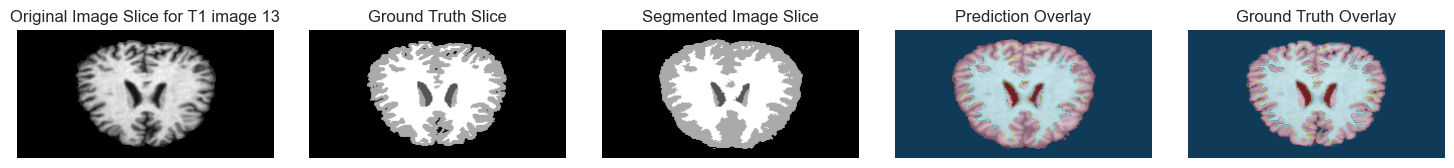

Dice Score: CSF: 0.7912211592571751, GM: 0.846271757473043, WM: 0.815703920319086, Avg: 0.8177322790164346


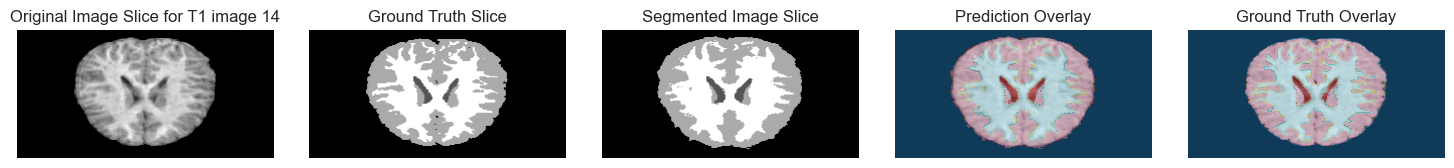

Dice Score: CSF: 0.8428153501979005, GM: 0.8426629525075487, WM: 0.8488380306562124, Avg: 0.844772111120554


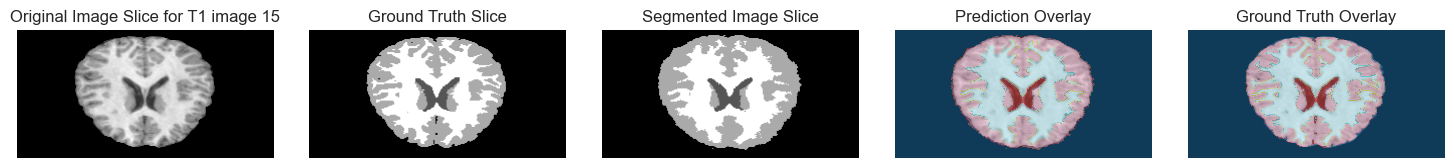

Dice Score: CSF: 0.8807704066034852, GM: 0.8575458086482356, WM: 0.8239139338950098, Avg: 0.8540767163822435


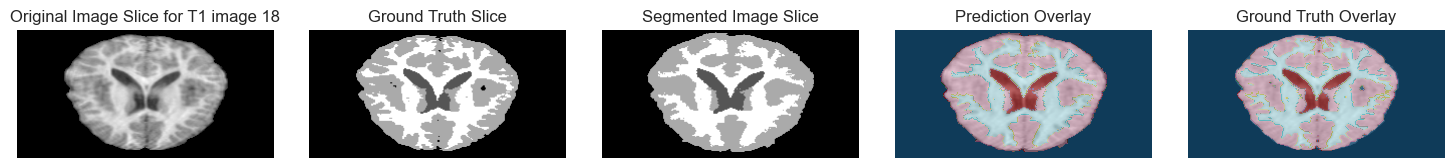

In [5]:
val_idx = [11, 12, 13, 14, 17]
for idx in val_idx:
    try:
        val_image = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}.nii.gz'))
        gt_label = sitk.GetArrayFromImage(sitk.ReadImage(f'Validation_Set/IBSR_{idx}/IBSR_{idx}_seg.nii.gz'))
        val_label = sitk.GetArrayFromImage(sitk.ReadImage(f"top_atlas_val_pred/top_atlases_label_IBSR_{idx}_normalized.nii.gz"))
        show_results(val_image, gt_label, val_label, modality='T1', i=idx, slice_idx=150, plot=True, show_hist=False, cmap='tab20')
    except Exception as e:
        print(f"Error: {e}")

## Voxel Morph Registration

In [10]:
for val_file in tqdm(val_images, desc="Validation Images"):
    df_val = None
    if not val_file.endswith(('.nii', '.nii.gz')):
        continue
    val_image = itk.imread(val_file, itk.F)
    val_label = itk.imread(val_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)

    # Iterate through each training image
    for train_file in tqdm(train_images, desc="Training Images"):
        if not train_file.endswith(('.nii', '.nii.gz')):
            continue
        train_image = itk.imread(train_file, itk.F)
        # train_label = itk.imread(train_file.replace('_normalized.nii.gz', '_seg.nii.gz'), itk.F)

        #register using voxelmorph
        moved, moved_label, warp, fixed_affine = voxmorph_register(val_file, train_file, train_file.replace('_normalized.nii.gz', '_seg.nii.gz'))

        train_id = os.path.basename(train_file)
        val_id = os.path.basename(val_file)
        # save moved image and label
        moved_path = str(f'voxelmorph/moved_{train_id}_to_{val_id}.nii.gz')
        moved_label_path = str(f'voxelmorph/moved_labels_{train_id}_to_{val_id}.nii.gz')
        vxm.py.utils.save_volfile(moved.squeeze(), moved_path, fixed_affine)
        vxm.py.utils.save_volfile(np.rint(moved_label.squeeze()), moved_label_path, fixed_affine)

        new_label = sitk.GetArrayFromImage(sitk.ReadImage(moved_label_path))
        # compute metrics
        mmi = compute_mattes_mi(moved_path, val_file)
        csf = dice_coefficient(new_label, itk.GetArrayFromImage(val_label), 1)
        gm = dice_coefficient(new_label, itk.GetArrayFromImage(val_label), 2)
        wm = dice_coefficient(new_label, itk.GetArrayFromImage(val_label), 3)
        
        dice = [csf, gm, wm]
        metric = mmi
        df = pd.DataFrame([[train_id] + dice+[metric]], columns=['train_id', 'CSF', 'GM', 'WM', 'metric'])
        df_val = pd.concat([df_val, df], ignore_index=True)
    
    # arange in descending order (most negative metric is the best)
    df_val = df_val.sort_values(by='metric', ascending=True)
    df_val.to_csv(str(f'voxelmorph/registration_result_{val_id}.csv'), index=False)

Validation Images:   0%|          | 0/5 [00:00<?, ?it/s]

Using device: /cpu:0


int_downsize is deprecated, use the int_resolution parameter.
unet_half_res is deprecated, use the svf_resolution parameter.



1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 598ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 617ms/step


Using device: /cpu:0
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 624ms/step


...

Using device: /cpu:0
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step


Using device: /cpu:0
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 654ms/step


Using device: /cpu:0
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 609ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step


Using device: /cpu:0
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step


Validation Images: 100%|██████████| 5/5 [11:26<00:00, 137.26s/it]


## Result Analysis

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

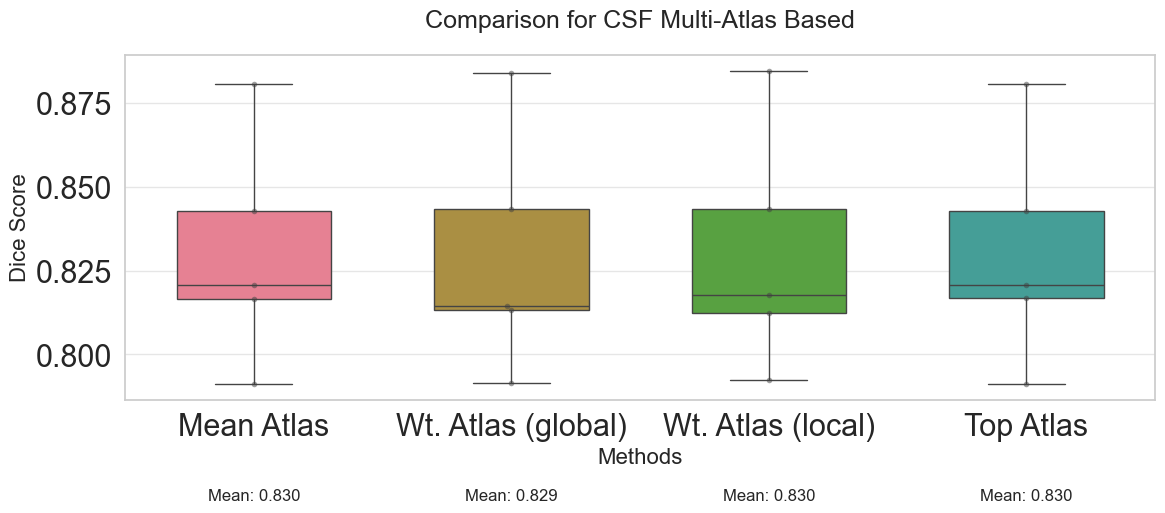

In [15]:
csf_values_mean_atlas = [0.8166,0.8207,0.7912,0.8428,0.8807,]
csf_values_weighted_atlas_global = [0.8145,0.8133,0.7914,0.8434,0.8839,]
csf_values_weighted_atlas_local = [0.8177,0.8124,0.7923,0.8435,0.8847,]
csf_values_top_atlas = [0.8167,0.8207,0.7912,0.8428,0.8808,]

data = {
    'Mean Atlas': csf_values_mean_atlas,
    'Wt. Atlas (global)': csf_values_weighted_atlas_global,
    'Wt. Atlas (local)': csf_values_weighted_atlas_local,
    'Top Atlas': csf_values_top_atlas,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for CSF Multi-Atlas Based', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

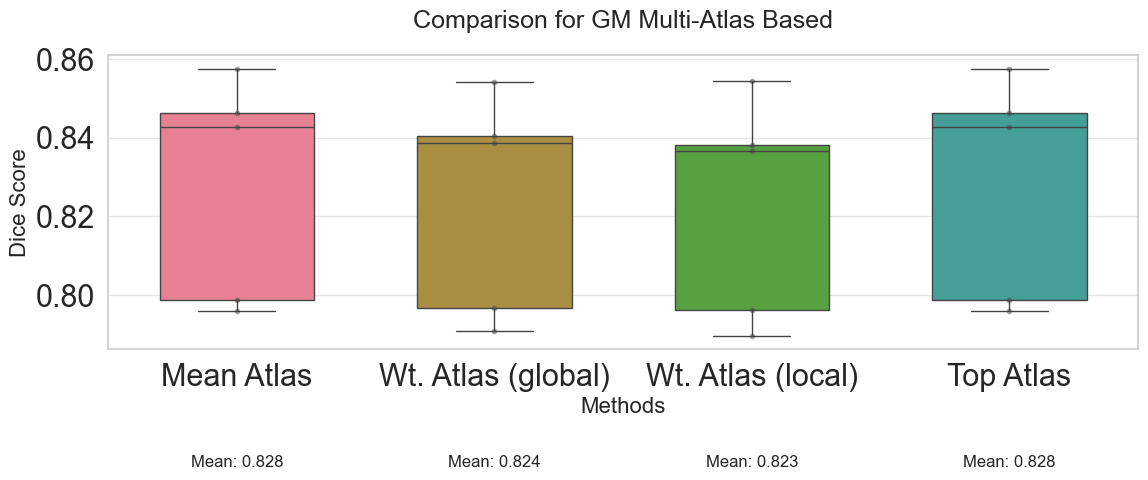

In [14]:
gm_values_mean_atlas = [0.7986,0.7959,0.8462,0.8427,0.8575,]
gm_values_weighted_atlas_global = [0.7967,0.7909,0.8405,0.8386,0.8542,]
gm_values_weighted_atlas_local = [0.7961,0.7896,0.8366,0.8381,0.8543,]
gm_values_top_atlas = [0.7987,0.7959,0.8463,0.8427,0.8575,]
data = {
    'Mean Atlas': gm_values_mean_atlas,
    'Wt. Atlas (global)': gm_values_weighted_atlas_global,
    'Wt. Atlas (local)': gm_values_weighted_atlas_local,
    'Top Atlas': gm_values_top_atlas,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for GM Multi-Atlas Based', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Methods', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

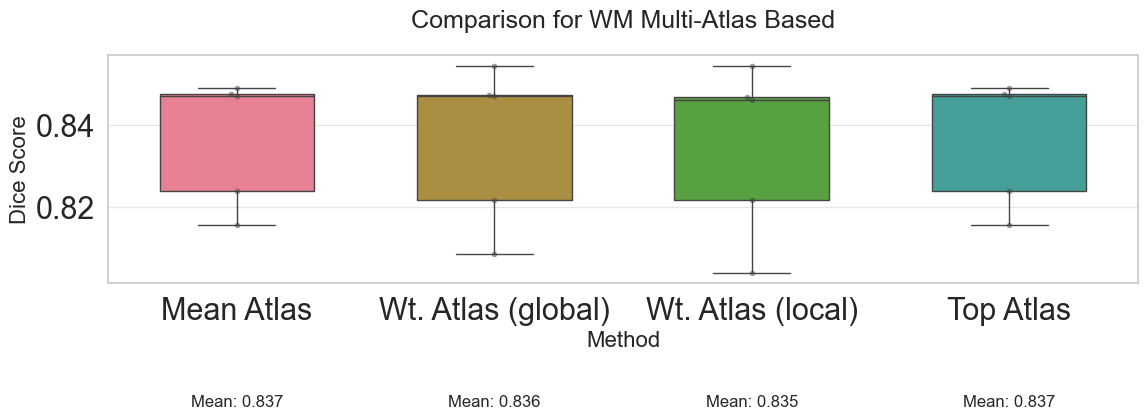

In [13]:
wm_values_mean_atlas = [0.8474,0.8469,0.8157,0.8488,0.8239,]
wm_values_weighted_atlas_global = [0.8543,0.8469,0.8088,0.8472,0.8219,]
wm_values_weighted_atlas_local = [0.8541,0.8461,0.8042,0.8468,0.8219,]
wm_values_top_atlas = [0.8474,0.8469,0.8157,0.8488,0.8239,]
data = {
    'Mean Atlas': wm_values_mean_atlas,
    'Wt. Atlas (global)': wm_values_weighted_atlas_global,
    'Wt. Atlas (local)': wm_values_weighted_atlas_local,
    'Top Atlas': wm_values_top_atlas,

}
df = pd.DataFrame(data)
sns.set_palette("husl")
plt.figure(figsize=(12, 6))
box_plot = sns.boxplot(data=df, width=0.6)
sns.swarmplot(data=df, color=".25", size=4, alpha=0.5)
plt.title('Comparison for WM Multi-Atlas Based', pad=20, size=18)
plt.ylabel('Dice Score', size=16)
plt.xlabel('Method', size=16)
# Add mean values as text
for i, method in enumerate(df.columns):
    mean_val = df[method].mean()
    plt.text(i, plt.ylim()[0] - 0.03, f'Mean: {mean_val:.3f}', 
             horizontalalignment='center', size=12)

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()